# Row-by-row SPICE electrical simulation + shaded-cell temperature fit

This notebook repeats the electrical simulation for **every valid row in `ivdata`**.

For each row it:

1. Reads that row's irradiance, shade percentage, `Middle_Temp`, and measured shaded-cell temperature.
2. Calculates the row-specific shaded irradiance:
   \[
   G_\mathrm{shaded}=G_\mathrm{unshaded}\left(1-\frac{\mathrm{Shade\ Percentage}}{100}\right)
   \]
3. Rebuilds and runs the SPICE module model.
4. Finds the module MPP and extracts the shaded cell's electrical power at that MPP.
5. Converts reverse-bias electrical dissipation to a heat flux.
6. Fits one cell-level Faiman-style model to all successful rows:
   \[
   T_\mathrm{cell}=T_\mathrm{amb}+
   \frac{G_\mathrm{shaded}+P_\mathrm{reverse}/A_\mathrm{cell}}
        {U_0+U_1\,v_\mathrm{wind}}
   \]

The fitted parameters are `U0` and `U1`.

> **Calibration note:** to preserve the electrical model used in the original notebook, each SPICE run uses that row's measured shaded-cell temperature when calculating the shaded-cell CEC parameters. This is appropriate for estimating electrical dissipation during calibration, but a fully predictive thermal/electrical model would later need to solve electrical power and cell temperature self-consistently.

In [1]:
import os
import shutil
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

project_root = Path.cwd().parents[1]
os.chdir(project_root)   # now cwd is .../pvcracks

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pvlib
from scipy.optimize import curve_fit

from pvcracks.pvspice.spice_tools import run_ngspice
from pvcracks.pvspice.spice_tools import module_to_netlist


# ------------------------------------------------------------------
# Cross-platform project root
# ------------------------------------------------------------------
def find_project_root(start=None):
    """
    Find the pvcracks project root by walking upward until Data.csv
    and the pvcracks package directory are found.
    """
    start = Path.cwd() if start is None else Path(start).resolve()

    for candidate in [start, *start.parents]:
        data_file = candidate / "docs" / "data" / "IVshaded" / "Data.csv"
        package_dir = candidate / "pvcracks"

        if data_file.exists() and package_dir.exists():
            return candidate

    raise FileNotFoundError(
        "Could not find the pvcracks project root. "
        "Start Jupyter from somewhere inside the pvcracks repository, "
        "or set project_root manually."
    )


project_root = find_project_root()
print("Project root:", project_root)


# ------------------------------------------------------------------
# Cross-platform ngspice executable
# ------------------------------------------------------------------
def find_ngspice():
    # Linux / conda / PATH
    exe = shutil.which("ngspice")
    if exe:
        return Path(exe)

    # Common Windows installs
    candidates = [
        Path(r"C:\Program Files\ngspice-47_64\Spice64\bin\ngspice.exe"),
        Path(r"C:\Program Files\ngspice-46_64\Spice64\bin\ngspice.exe"),
        Path(r"C:\Program Files\ngspice-45_64\Spice64\bin\ngspice.exe"),
        Path(r"C:\Program Files\ngspice\bin\ngspice.exe"),
    ]

    for candidate in candidates:
        if candidate.exists():
            return candidate

    return None


spicepath = find_ngspice()

if spicepath is None:
    raise FileNotFoundError(
        "ngspice was not found. If it is installed, set spicepath manually, e.g.\n"
        r'Windows: spicepath = Path(r"C:\Program Files\ngspice-47_64\Spice64\bin\ngspice.exe")' "\n"
        'Linux:   spicepath = Path("/usr/bin/ngspice")'
    )

print("ngspice:", spicepath)


# A dedicated folder avoids mixing the fit output with the source data.
spice_workdir = project_root / "docs" / "data" / "IVshaded" / "_thermal_fit_spice"
spice_workdir.mkdir(parents=True, exist_ok=True)

# Each simulation gets its own folder, so several ngspice batch jobs can
# run safely at once. Reduce this if the computer is busy.
MAX_SPICE_WORKERS = min(4, os.cpu_count() or 1)

print("SPICE working directory:", spice_workdir)
print("Concurrent ngspice workers:", MAX_SPICE_WORKERS)

Project root: c:\Users\Norman\pvcracks
ngspice: C:\Program Files\ngspice-47_64\Spice64\bin\ngspice.exe
SPICE working directory: c:\Users\Norman\pvcracks\docs\data\IVshaded\_thermal_fit_spice
Concurrent ngspice workers: 4


In [2]:
# ------------------------------------------------------------------
# Load experimental IV data
# ------------------------------------------------------------------
data_file = project_root / "docs" / "data" / "IVshaded" / "Data.csv"
ivdata = pd.read_csv(data_file)

# Parse time for easier inspection; the original string values are not
# needed by SPICE itself.
ivdata["Date_Time"] = pd.to_datetime(ivdata["Date_Time"], errors="coerce")

print("Rows in ivdata:", len(ivdata))
display(ivdata.head())
print()
print(ivdata.dtypes)

Rows in ivdata: 39


,Date_Time,Irradiance_61,Voltage,Current,Amb_Temp,wind_speed,Observed_Temp of Shaded Cell,Bias_V,Reverse_Bias_I (Shaded Cell),Reverse_Bias_V (Shaded Cell),Shade_Percentage,Middle_Temp
0,2025-09-14 12:06:10,989.21,"[0.0, 2.996794, 2.999425, 3.428385, 3.638917, ...","[10.130262, 10.130262, 10.157452, 10.166516, 1...",27.16882,3.404462,82.4,5,5.42,-10.55,49.0,44.11791
1,2025-09-14 12:08:10,992.72,"[0.0, 3.009952, 3.009952, 3.280354, 3.494176, ...","[10.172559, 10.172559, 10.202168, 10.196125, 1...",27.24812,2.778292,81.5,5,5.53,-10.51,48.0,44.37752
2,2025-09-14 12:09:10,993.33,"[0.0, 3.013242, 3.013242, 3.441543, 3.651417, ...","[10.175192, 10.175192, 10.200569, 10.199965, 1...",26.99375,1.411265,81.6,5,5.51,-10.53,48.0,44.86721
3,2025-09-14 12:14:10,997.45,"[0.0, 3.0264, 3.031663, 3.454043, 3.666549, 3....","[10.225771, 10.225771, 10.242084, 10.239063, 1...",27.17725,3.404462,90.7,10,5.46,-10.51,49.0,44.88346
4,2025-09-14 12:15:10,998.06,"[0.0, 2.986925, 2.988899, 3.416542, 3.627074, ...","[10.22275, 10.22275, 10.243292, 10.24873, 10.2...",27.14147,2.063804,88.8,10,5.55,-10.49,49.0,44.65374



Date_Time                       datetime64[ns]
Irradiance_61                          float64
Voltage                                 object
Current                                 object
Amb_Temp                               float64
wind_speed                             float64
Observed_Temp of Shaded Cell           float64
Bias_V                                   int64
Reverse_Bias_I (Shaded Cell)           float64
Reverse_Bias_V (Shaded Cell)           float64
Shade_Percentage                       float64
Middle_Temp                            float64
dtype: object


In [3]:
# ------------------------------------------------------------------
# Load the CEC module and fixed module geometry/model parameters
# ------------------------------------------------------------------
cec_modules = pvlib.pvsystem.retrieve_sam("CECMod")

query = "LG320N1K-A5"
query_norm = query.replace("-", "_").upper()

matches = [
    name for name in cec_modules.columns
    if query_norm in name.upper().replace("-", "_")
]

if not matches:
    raise ValueError(f"No CEC module match found for {query!r}")

module_name = matches[0]
module_data = cec_modules[module_name].copy()

print("Selected CEC module:", module_name)

N_s = 60
N_modules = 1
N_byp = 2

n_rows = 6
n_cols = 10

# Bottom-left physical cell: row 5, col 0
shaded_cell_index = 5 * n_cols + 0

md = module_data

I_sc_ref = float(md["I_sc_ref"])
V_oc_ref = float(md["V_oc_ref"])
I_mp_ref = float(md["I_mp_ref"])
V_mp_ref = float(md["V_mp_ref"])
alpha_sc = float(md["alpha_sc"])
beta_oc = float(md["beta_oc"])
a_ref = float(md["a_ref"])
I_L_ref = float(md["I_L_ref"])
I_o_ref = float(md["I_o_ref"])
R_s_ref = float(md["R_s"])
R_sh_ref = float(md["R_sh_ref"])
Adjust = float(md["Adjust"])

if I_o_ref <= 0 or not np.isfinite(I_o_ref):
    I_o_ref = (I_L_ref - V_oc_ref / R_sh_ref) / np.expm1(V_oc_ref / a_ref)

A_module = float(module_data["A_c"])
A_cell = A_module / N_s

# Same SPICE settings as the original notebook
breakdown_voltage = 12.0
v_bypass = 100.0

print("Shaded cell index:", shaded_cell_index)
print("Module area [m^2]:", A_module)
print("Cell area [m^2]:", A_cell)
print("CEC I_o_ref [A]:", I_o_ref)

Selected CEC module: LG_Electronics_Inc__LG320N1K_A5
Shaded cell index: 50
Module area [m^2]: 1.649
Cell area [m^2]: 0.027483333333333335
CEC I_o_ref [A]: 1.00861e-11


In [4]:
# Read cell-level IVs from ngspice ASCII output
def ngspice_read_cell_level_ivs(
    path,
    N_s=60,
    series_resistances=None,
    output_filename="solar_circuit.out",
    current_col="i(v1)",
    flip_module_current_if_negative=True,
):
    """
    Read ngspice ASCII raw output and reconstruct cell-level IV data.

    Parameters
    ----------
    path : str
        Folder containing the ngspice output file.
    N_s : int
        Number of cells in the module.
    series_resistances : float, list, or array, optional
        Per-cell series resistance values used in the SPICE netlist.
        If provided, cell current is calculated from voltage across each Rs.
        If None, only cell voltages are returned.
    output_filename : str
        Name of ngspice output file. Default is 'solar_circuit.out'.
    current_col : str
        Name of module current column in ngspice output. Usually 'i(v1)'.
    flip_module_current_if_negative : bool
        If True, flips module current sign when median current is negative.

    Returns
    -------
    df_cells_long : pandas.DataFrame
        Long-format cell-level IV dataframe with columns:
        sweep_V, module_V, module_I, cell, V_cell, V_diode, V_rs,
        and I_cell if series_resistances is provided.

    df_cells_wide : pandas.DataFrame
        Wide-format dataframe with one row per sweep point and columns:
        sweep_V, module_V, module_I, V_cell_0 ... V_cell_N,
        and optionally I_cell_0 ... I_cell_N.

    df_raw : pandas.DataFrame
        Raw ngspice variables as columns.

    Notes
    -----
    This assumes the standard non-halfcut pvspice node pattern:

        cell n:
            Rs_n from node 2n+1 to node 2n+2
            diode/Rp/current source from node 2n+2 to node 2n+3

        last cell ends at ground node 0.

    Therefore:
        V_cell_n = V(2n+1) - V(2n+3)
        V_diode_n = V(2n+2) - V(2n+3)
        V_rs_n = V(2n+1) - V(2n+2)

    For the last cell, V(2n+3) is replaced with ground, 0 V.
    """

    from pathlib import Path
    import numpy as np
    import pandas as pd

    output_file = Path(path) / output_filename

    with open(output_file, "r") as f:
        lines = f.readlines()

    # ---------------------------------------------------------
    # Parse header information
    # ---------------------------------------------------------
    nvars = None
    npoints = None
    variables_start = None
    values_start = None

    for i, line in enumerate(lines):
        s = line.strip()

        if s.startswith("No. Variables:"):
            nvars = int(s.split(":")[1].strip())

        if s.startswith("No. Points:"):
            npoints = int(s.split(":")[1].strip())

        if s.startswith("Variables:"):
            variables_start = i + 1

        if s.startswith("Values:"):
            values_start = i + 1
            break

    if nvars is None:
        raise ValueError("Could not find 'No. Variables:' in ngspice output.")

    if variables_start is None:
        raise ValueError("Could not find 'Variables:' section in ngspice output.")

    if values_start is None:
        raise ValueError("Could not find 'Values:' section in ngspice output.")

    # ---------------------------------------------------------
    # Parse variable names
    # ---------------------------------------------------------
    var_names = []

    for line in lines[variables_start:values_start - 1]:
        parts = line.split()

        if len(parts) >= 2:
            var_names.append(parts[1])

    if len(var_names) != nvars:
        raise ValueError(
            f"Expected {nvars} variables, but parsed {len(var_names)} variable names."
        )

    # ---------------------------------------------------------
    # Parse values
    # ---------------------------------------------------------
    data = []
    current_point = []

    for line in lines[values_start:]:
        s = line.strip()

        if s == "":
            continue

        parts = s.split()

        # First line of each point looks like:
        #     0    0.000000e+00
        # Continuation lines look like:
        #          5.176018e-02
        if len(parts) >= 2:
            try:
                int(parts[0])
                value = float(parts[1])
            except ValueError:
                value = float(parts[0])
        else:
            value = float(parts[0])

        current_point.append(value)

        if len(current_point) == nvars:
            data.append(current_point)
            current_point = []

    df_raw = pd.DataFrame(data, columns=var_names)

    if npoints is not None and len(df_raw) != npoints:
        print(
            f"Warning: header says {npoints} points, "
            f"but parsed {len(df_raw)} points."
        )

    # ---------------------------------------------------------
    # Identify sweep/module voltage and current
    # ---------------------------------------------------------
    if "v(v-sweep)" in df_raw.columns:
        sweep_V = df_raw["v(v-sweep)"].to_numpy(dtype=float)
    else:
        sweep_V = df_raw.iloc[:, 0].to_numpy(dtype=float)

    if "v(1)" in df_raw.columns:
        module_V = df_raw["v(1)"].to_numpy(dtype=float)
    else:
        module_V = sweep_V.copy()

    if current_col in df_raw.columns:
        module_I = df_raw[current_col].to_numpy(dtype=float)
    else:
        matching_current_cols = [c for c in df_raw.columns if c.lower().startswith("i(")]
        if len(matching_current_cols) == 0:
            raise ValueError("Could not find any current column like i(v1).")
        current_col = matching_current_cols[-1]
        print(f"Using current column: {current_col}")
        module_I = df_raw[current_col].to_numpy(dtype=float)

    if flip_module_current_if_negative and np.nanmedian(module_I) < 0:
        module_I = -module_I

    # ---------------------------------------------------------
    # Expand series resistance array if provided
    # ---------------------------------------------------------
    calculate_cell_current = series_resistances is not None

    if calculate_cell_current:
        if np.isscalar(series_resistances):
            Rs_cells = np.full(N_s, float(series_resistances))
        else:
            Rs_cells = np.asarray(series_resistances, dtype=float)

            if len(Rs_cells) == 1:
                Rs_cells = np.full(N_s, float(Rs_cells[0]))
            elif len(Rs_cells) != N_s:
                raise ValueError(
                    f"series_resistances must have length 1 or N_s={N_s}, "
                    f"but got length {len(Rs_cells)}."
                )

    # ---------------------------------------------------------
    # Reconstruct cell voltages and currents
    # ---------------------------------------------------------
    df_cells_wide = pd.DataFrame()
    df_cells_wide["sweep_V"] = sweep_V
    df_cells_wide["module_V"] = module_V
    df_cells_wide["module_I"] = module_I

    long_rows = []

    n_points = len(df_raw)

    for n in range(N_s):
        start_node = 2 * n + 1
        after_rs_node = 2 * n + 2

        if n == N_s - 1:
            end_node = 0
        else:
            end_node = 2 * n + 3

        start_col = f"v({start_node})"
        after_rs_col = f"v({after_rs_node})"

        if start_col not in df_raw.columns:
            raise ValueError(f"Missing node voltage column {start_col}")

        if after_rs_col not in df_raw.columns:
            raise ValueError(f"Missing node voltage column {after_rs_col}")

        V_start = df_raw[start_col].to_numpy(dtype=float)
        V_after_rs = df_raw[after_rs_col].to_numpy(dtype=float)

        if end_node == 0:
            V_end = np.zeros(n_points)
        else:
            end_col = f"v({end_node})"

            if end_col not in df_raw.columns:
                raise ValueError(f"Missing node voltage column {end_col}")

            V_end = df_raw[end_col].to_numpy(dtype=float)

        # Full cell terminal voltage, including Rs
        V_cell = V_start - V_end

        # Diode/Rp/current-source junction voltage, excluding Rs
        V_diode = V_after_rs - V_end

        # Series resistor voltage, using netlist orientation
        V_rs = V_start - V_after_rs

        df_cells_wide[f"V_cell_{n}"] = V_cell
        df_cells_wide[f"V_diode_{n}"] = V_diode
        df_cells_wide[f"V_rs_{n}"] = V_rs

        if calculate_cell_current:
            # Positive PV current convention for your netlist
            I_cell = (V_after_rs - V_start) / Rs_cells[n]
            df_cells_wide[f"I_cell_{n}"] = I_cell
        else:
            I_cell = np.full(n_points, np.nan)

        for k in range(n_points):
            long_rows.append(
                {
                    "sweep_V": sweep_V[k],
                    "module_V": module_V[k],
                    "module_I": module_I[k],
                    "cell": n,
                    "V_cell": V_cell[k],
                    "V_diode": V_diode[k],
                    "V_rs": V_rs[k],
                    "I_cell": I_cell[k],
                }
            )

    df_cells_long = pd.DataFrame(long_rows)

    return df_cells_long, df_cells_wide, df_raw

In [5]:
# ------------------------------------------------------------------
# One complete electrical simulation for one ivdata row
# ------------------------------------------------------------------
def simulate_row_electrical(row, workdir):
    """
    Repeat the original notebook's CEC + SPICE calculation for one row.

    Returns one dictionary containing the electrical result and the
    row-specific thermal heat-flux terms. ``workdir`` must be unique
    for concurrent SPICE jobs so their output files cannot collide.
    """

    # --------------------------------------------------------------
    # Row-specific measured/environmental inputs
    # --------------------------------------------------------------
    G_unshaded = float(row["Irradiance_61"])
    shade_pct = float(row["Shade_Percentage"])
    T_unshaded = float(row["Middle_Temp"])
    T_shaded = float(row["Observed_Temp of Shaded Cell"])
    T_amb = float(row["Amb_Temp"])
    wind_speed = float(row["wind_speed"])
    bias_voltage = float(row["Bias_V"])

    required = {
        "G_unshaded": G_unshaded,
        "shade_pct": shade_pct,
        "T_unshaded": T_unshaded,
        "T_shaded": T_shaded,
        "T_amb": T_amb,
        "wind_speed": wind_speed,
        "bias_voltage": bias_voltage,
    }

    if not all(np.isfinite(v) for v in required.values()):
        raise ValueError(f"Non-finite input value(s): {required}")

    shade_frac = np.clip(shade_pct / 100.0, 0.0, 1.0)
    G_shaded = G_unshaded * (1.0 - shade_frac)

    # --------------------------------------------------------------
    # CEC parameters: unshaded cells
    # --------------------------------------------------------------
    (
        IL_unshaded,
        I0_unshaded,
        Rs_module_unshaded,
        Rsh_module_unshaded,
        nNsVth_unshaded,
    ) = pvlib.pvsystem.calcparams_cec(
        effective_irradiance=max(G_unshaded, 1e-6),
        temp_cell=T_unshaded,
        alpha_sc=alpha_sc,
        a_ref=a_ref,
        I_L_ref=I_L_ref,
        I_o_ref=I_o_ref,
        R_sh_ref=R_sh_ref,
        R_s=R_s_ref,
        Adjust=Adjust,
    )

    # --------------------------------------------------------------
    # CEC parameters: shaded cell
    # --------------------------------------------------------------
    (
        IL_shaded,
        I0_shaded,
        Rs_module_shaded,
        Rsh_module_shaded,
        nNsVth_shaded,
    ) = pvlib.pvsystem.calcparams_cec(
        effective_irradiance=max(G_shaded, 1e-6),
        temp_cell=T_shaded,
        alpha_sc=alpha_sc,
        a_ref=a_ref,
        I_L_ref=I_L_ref,
        I_o_ref=I_o_ref,
        R_sh_ref=R_sh_ref,
        R_s=R_s_ref,
        Adjust=Adjust,
    )

    # Unshaded module Voc is used by the netlist generator
    sd_unshaded = pvlib.pvsystem.singlediode(
        photocurrent=IL_unshaded,
        saturation_current=I0_unshaded,
        resistance_series=Rs_module_unshaded,
        resistance_shunt=Rsh_module_unshaded,
        nNsVth=nNsVth_unshaded,
    )
    v_oc_sim = float(sd_unshaded["v_oc"])

    # Convert module-level CEC resistances to per-cell values
    Rs_cell_unshaded = float(Rs_module_unshaded) / N_s
    Rsh_cell_unshaded = float(Rsh_module_unshaded) / N_s

    Rs_cell_shaded = float(Rs_module_shaded) / N_s
    Rsh_cell_shaded = float(Rsh_module_shaded) / N_s

    # Same diode ideality calculation as the original notebook
    k_B = 1.380649e-23
    q_e = 1.602176634e-19
    T_K = T_unshaded + 273.15
    Vth_cell = k_B * T_K / q_e

    ideality_factor = float(nNsVth_unshaded) / (N_s * Vth_cell)
    saturation_current = float(I0_unshaded)

    # --------------------------------------------------------------
    # Build per-cell arrays
    # --------------------------------------------------------------
    cell_currents = np.full(N_s, float(IL_unshaded), dtype=float)
    series_resistances = np.full(N_s, Rs_cell_unshaded, dtype=float)
    shunt_resistances = np.full(N_s, Rsh_cell_unshaded, dtype=float)

    cell_currents[shaded_cell_index] = float(IL_shaded)
    series_resistances[shaded_cell_index] = Rs_cell_shaded
    shunt_resistances[shaded_cell_index] = Rsh_cell_shaded

    # --------------------------------------------------------------
    # Write and run the SPICE netlist
    # --------------------------------------------------------------
    workdir = Path(workdir)
    workdir.mkdir(parents=True, exist_ok=True)

    circuit_content, halfcut = module_to_netlist(
        path=str(workdir),
        N_s=N_s,
        cell_currents=cell_currents,
        series_resistances=series_resistances,
        shunt_resistances=shunt_resistances,
        ideality_factor=ideality_factor,
        saturation_current=saturation_current,
        breakdown_voltage=breakdown_voltage,
        v_bypass=v_bypass,
        v_oc=v_oc_sim,
        TNOM=T_unshaded,
        circuit_name="solar_circuit",
    )

    circuit_file = workdir / "solar_circuit.cir"

    run_ngspice(
        ngpsice_path=str(spicepath),
        circuit_file=circuit_file,
        capture_output=True,
    )

    # --------------------------------------------------------------
    # Read cell-level IVs and extract the measured bias-voltage point
    # --------------------------------------------------------------
    _, df_cells_wide, _ = ngspice_read_cell_level_ivs(
        path=workdir,
        N_s=N_s,
        series_resistances=series_resistances,
        output_filename="solar_circuit.out",
    )

    if len(df_cells_wide) == 0:
        raise RuntimeError("ngspice output contains no sweep points.")

    module_voltage = df_cells_wide["module_V"].to_numpy(dtype=float)
    module_current = df_cells_wide["module_I"].to_numpy(dtype=float)

    if not np.all(np.diff(module_voltage) >= 0):
        raise RuntimeError("ngspice module-voltage sweep is not monotonic.")

    if not module_voltage.min() <= bias_voltage <= module_voltage.max():
        raise ValueError(
            f"Bias_V={bias_voltage:.3f} V is outside the ngspice sweep "
            f"range {module_voltage.min():.3f}–{module_voltage.max():.3f} V."
        )

    # Interpolation keeps the thermal calculation at the measured module
    # bias voltage rather than at the nearest 0.1 V DC-sweep point.
    def value_at_bias(column):
        return float(
            np.interp(
                bias_voltage,
                module_voltage,
                df_cells_wide[column].to_numpy(dtype=float),
            )
        )

    V_operating_module = bias_voltage
    I_operating_module = value_at_bias("module_I")
    P_operating_module = V_operating_module * I_operating_module

    V_cell_operating = value_at_bias(f"V_cell_{shaded_cell_index}")
    I_cell_operating = value_at_bias(f"I_cell_{shaded_cell_index}")
    P_cell_elec_operating = V_cell_operating * I_cell_operating

    # --------------------------------------------------------------
    # Row-specific thermal source terms
    # --------------------------------------------------------------
    # Negative cell electrical power = electrical dissipation as heat.
    P_reverse_heat = max(0.0, -P_cell_elec_operating)

    q_reverse = P_reverse_heat / A_cell
    q_total = G_shaded + q_reverse

    return {
        "G_unshaded_W_m2": G_unshaded,
        "Bias_V": bias_voltage,
        "Shade_Percentage": shade_pct,
        "G_shaded_W_m2": G_shaded,
        "T_middle_C": T_unshaded,
        "T_shaded_measured_C": T_shaded,
        "T_amb_C": T_amb,
        "wind_speed_m_s": wind_speed,
        "V_operating_module_V": V_operating_module,
        "I_operating_module_A": I_operating_module,
        "P_operating_module_W": P_operating_module,
        "V_shaded_cell_operating_V": V_cell_operating,
        "I_shaded_cell_operating_A": I_cell_operating,
        "P_cell_elec_operating_W": P_cell_elec_operating,
        "P_reverse_heat_W": P_reverse_heat,
        "q_reverse_W_m2": q_reverse,
        "q_total_W_m2": q_total,
        # Keep the full module curve for the aggregate IV plots below.
        "module_voltage_V": module_voltage,
        "module_current_A": module_current,
    }

## Run SPICE for every row

This is the slow part because ngspice is executed once per row. Each run now gets its own folder and ngspice uses the hidden Windows console executable when available, so independent rows can run concurrently without colliding over `solar_circuit.cir` or `solar_circuit.out`.

Rows with missing inputs or SPICE errors are recorded with `status="error"` and the loop continues.

In [6]:
# ------------------------------------------------------------------
# Run one complete electrical simulation per ivdata row
# ------------------------------------------------------------------
def simulate_one_row(run_number, source_index, row):
    base = {
        "source_index": source_index,
        "Date_Time": row.get("Date_Time", pd.NaT),
        "Bias_V": pd.to_numeric(row.get("Bias_V"), errors="coerce"),
    }

    try:
        # module_to_netlist always writes solar_circuit.*. A unique folder
        # makes those fixed filenames safe for concurrent runs.
        result = simulate_row_electrical(
            row, workdir=spice_workdir / f"row_{run_number:03d}"
        )
        base.update(result)
        base["status"] = "ok"
        base["error_message"] = ""

    except Exception as exc:
        # Keep enough source information to diagnose failed rows.
        base.update({
            "G_unshaded_W_m2": pd.to_numeric(row.get("Irradiance_61"), errors="coerce"),
            "Shade_Percentage": pd.to_numeric(row.get("Shade_Percentage"), errors="coerce"),
            "Bias_V": pd.to_numeric(row.get("Bias_V"), errors="coerce"),
            "T_middle_C": pd.to_numeric(row.get("Middle_Temp"), errors="coerce"),
            "T_shaded_measured_C": pd.to_numeric(
                row.get("Observed_Temp of Shaded Cell"), errors="coerce"
            ),
            "T_amb_C": pd.to_numeric(row.get("Amb_Temp"), errors="coerce"),
            "wind_speed_m_s": pd.to_numeric(row.get("wind_speed"), errors="coerce"),
            "status": "error",
            "error_message": f"{type(exc).__name__}: {exc}",
        })

    return base


n_total = len(ivdata)
simulation_rows = [None] * n_total
max_workers = max(1, int(MAX_SPICE_WORKERS))

with ThreadPoolExecutor(max_workers=max_workers) as executor:
    future_to_position = {
        executor.submit(simulate_one_row, run_number, source_index, row): run_number - 1
        for run_number, (source_index, row) in enumerate(ivdata.iterrows(), start=1)
    }

    for completed_number, future in enumerate(as_completed(future_to_position), start=1):
        position = future_to_position[future]
        simulation_rows[position] = future.result()

        # Progress without flooding the notebook. Completion order may differ
        # from the source-data order when jobs run concurrently.
        if (
            completed_number == 1
            or completed_number % 10 == 0
            or completed_number == n_total
        ):
            n_ok = sum(
                r is not None and r.get("status") == "ok"
                for r in simulation_rows
            )
            print(
                f"{completed_number:4d}/{n_total} rows completed | successful: {n_ok}"
            )


electrical_results = pd.DataFrame(simulation_rows)

print()
print("Finished.")
print(electrical_results["status"].value_counts(dropna=False))

display(electrical_results.head())

All series interconnection of 60 solar cells
All series interconnection of 60 solar cells
All series interconnection of 60 solar cells
All series interconnection of 60 solar cells


C:\Users\Norman\AppData\Local\Temp\ipykernel_36832\2972844513.py:260: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_cells_wide[f"V_diode_{n}"] = V_diode
C:\Users\Norman\AppData\Local\Temp\ipykernel_36832\2972844513.py:260: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_cells_wide[f"V_diode_{n}"] = V_diode
C:\Users\Norman\AppData\Local\Temp\ipykernel_36832\2972844513.py:261: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consi

   1/39 rows completed | successful: 1
All series interconnection of 60 solar cells
All series interconnection of 60 solar cells


C:\Users\Norman\AppData\Local\Temp\ipykernel_36832\2972844513.py:260: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_cells_wide[f"V_diode_{n}"] = V_diode
C:\Users\Norman\AppData\Local\Temp\ipykernel_36832\2972844513.py:261: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_cells_wide[f"V_rs_{n}"] = V_rs
C:\Users\Norman\AppData\Local\Temp\ipykernel_36832\2972844513.py:266: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider jo

All series interconnection of 60 solar cells
All series interconnection of 60 solar cells


...

All series interconnection of 60 solar cells
All series interconnection of 60 solar cells
All series interconnection of 60 solar cells


C:\Users\Norman\AppData\Local\Temp\ipykernel_36832\2972844513.py:259: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_cells_wide[f"V_cell_{n}"] = V_cell
C:\Users\Norman\AppData\Local\Temp\ipykernel_36832\2972844513.py:260: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_cells_wide[f"V_diode_{n}"] = V_diode
C:\Users\Norman\AppData\Local\Temp\ipykernel_36832\2972844513.py:261: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Conside

  39/39 rows completed | successful: 39

Finished.
status
ok    39
Name: count, dtype: int64


C:\Users\Norman\AppData\Local\Temp\ipykernel_36832\2972844513.py:260: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_cells_wide[f"V_diode_{n}"] = V_diode
C:\Users\Norman\AppData\Local\Temp\ipykernel_36832\2972844513.py:261: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_cells_wide[f"V_rs_{n}"] = V_rs
C:\Users\Norman\AppData\Local\Temp\ipykernel_36832\2972844513.py:266: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider jo

,source_index,Date_Time,Bias_V,G_unshaded_W_m2,Shade_Percentage,G_shaded_W_m2,T_middle_C,T_shaded_measured_C,T_amb_C,wind_speed_m_s,...,V_shaded_cell_operating_V,I_shaded_cell_operating_A,P_cell_elec_operating_W,P_reverse_heat_W,q_reverse_W_m2,q_total_W_m2,module_voltage_V,module_current_A,status,error_message
0,0,2025-09-14 12:06:10,5.0,989.21,49.0,504.4971,44.11791,82.4,27.16882,3.404462,...,-11.603460,6.329629,-73.445593,73.445593,2672.368439,3176.865539,"[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.799...","[10.11457972581412, 10.11410256665602, 10.1136...",ok,
1,1,2025-09-14 12:08:10,5.0,992.72,48.0,516.2144,44.37752,81.5,27.24812,2.778292,...,-11.565048,6.471834,-74.847074,74.847074,2723.362288,3239.576688,"[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.799...","[10.15093593941658, 10.1504570892846, 10.14997...",ok,
2,2,2025-09-14 12:09:10,5.0,993.33,48.0,516.5316,44.86721,81.6,26.99375,1.411265,...,-11.548061,6.474215,-74.764636,74.764636,2720.362752,3236.894352,"[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.799...","[10.15810754702017, 10.15762840286635, 10.1571...",ok,
3,3,2025-09-14 12:14:10,10.0,997.45,49.0,508.6995,44.88346,90.7,27.17725,3.404462,...,-11.574217,6.387653,-73.932085,73.932085,2690.069806,3198.769306,"[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.799...","[10.20022528781007, 10.19974415786204, 10.1992...",ok,
4,4,2025-09-14 12:15:10,10.0,998.06,49.0,509.0106,44.65374,88.8,27.14147,2.063804,...,-11.582523,6.390496,-74.018067,74.018067,2693.198308,3202.208908,"[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.799...","[10.20601382606104, 10.20553240216636, 10.2050...",ok,


All rows simulated successfully.


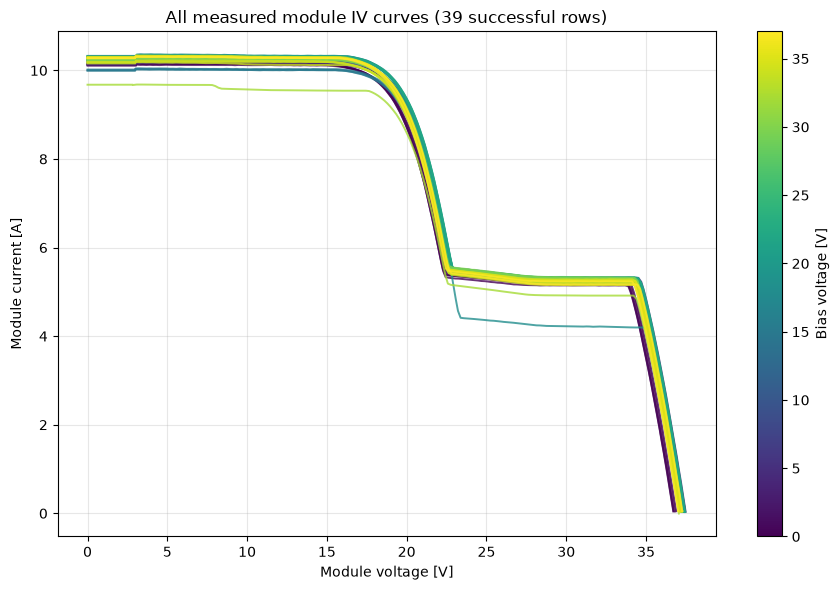

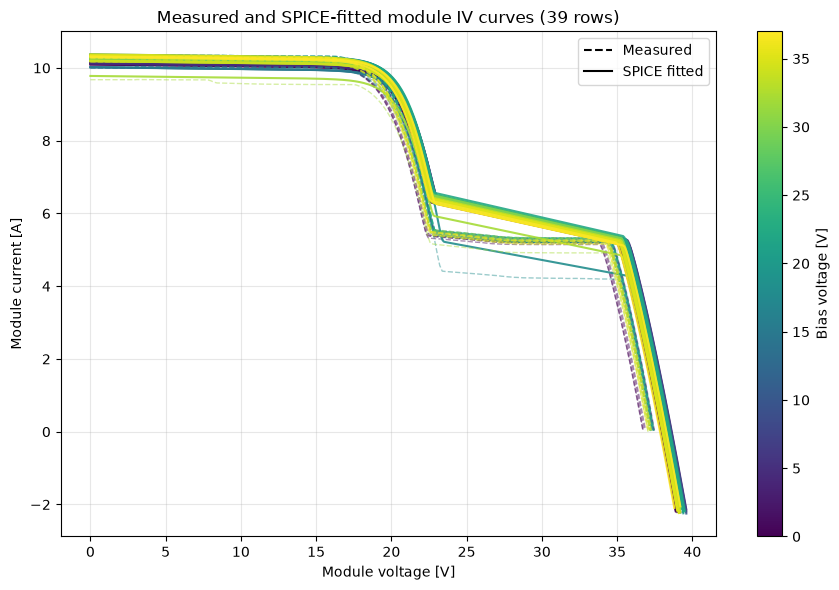

In [7]:
# ------------------------------------------------------------------
# Inspect failed simulations, if any
# ------------------------------------------------------------------
failed = electrical_results.query("status != 'ok'").copy()

if len(failed):
    display(
        failed[
            [
                "source_index",
                "Date_Time",
                "G_unshaded_W_m2",
                "Shade_Percentage",
                "T_middle_C",
                "T_shaded_measured_C",
                "T_amb_C",
                "wind_speed_m_s",
                "error_message",
            ]
        ]
    )
else:
    print("All rows simulated successfully.")


# ------------------------------------------------------------------
# Aggregate measured and SPICE module IV curves
# ------------------------------------------------------------------
import ast
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D


def parse_iv_series(value, column_name):
    """Convert a list stored in Data.csv to a finite float array."""
    if isinstance(value, str):
        value = ast.literal_eval(value)

    values = np.asarray(value, dtype=float)
    if values.ndim != 1:
        raise ValueError(f"{column_name} is not a one-dimensional IV series.")

    return values


iv_curves = []
for _, simulation in electrical_results.loc[
    electrical_results["status"].eq("ok")
].iterrows():
    try:
        measurement = ivdata.loc[simulation["source_index"]]
        V_measured = parse_iv_series(measurement["Voltage"], "Voltage")
        I_measured = parse_iv_series(measurement["Current"], "Current")
        V_fitted = np.asarray(simulation["module_voltage_V"], dtype=float)
        I_fitted = np.asarray(simulation["module_current_A"], dtype=float)

        if len(V_measured) != len(I_measured):
            raise ValueError("Measured voltage and current arrays have different lengths.")
        if len(V_fitted) != len(I_fitted):
            raise ValueError("SPICE voltage and current arrays have different lengths.")

        measured_finite = np.isfinite(V_measured) & np.isfinite(I_measured)
        fitted_finite = np.isfinite(V_fitted) & np.isfinite(I_fitted)
        bias_voltage = float(simulation["Bias_V"])

        if not np.isfinite(bias_voltage):
            raise ValueError("Bias_V is not finite.")
        if measured_finite.sum() < 2 or fitted_finite.sum() < 2:
            raise ValueError("An IV curve has fewer than two finite points.")

        iv_curves.append({
            "Bias_V": bias_voltage,
            "V_measured": V_measured[measured_finite],
            "I_measured": I_measured[measured_finite],
            "V_fitted": V_fitted[fitted_finite],
            "I_fitted": I_fitted[fitted_finite],
        })

    except Exception as exc:
        print(
            f"Skipping IV plot for source row {simulation['source_index']}: "
            f"{type(exc).__name__}: {exc}"
        )


if not iv_curves:
    print("No complete measured/SPICE IV pairs are available to plot.")
else:
    iv_curves.sort(key=lambda curve: curve["Bias_V"])
    bias_values = np.asarray([curve["Bias_V"] for curve in iv_curves])
    bias_min = float(bias_values.min())
    bias_max = float(bias_values.max())
    if np.isclose(bias_min, bias_max):
        bias_min -= 0.5
        bias_max += 0.5

    norm = Normalize(vmin=bias_min, vmax=bias_max)
    cmap = plt.get_cmap("viridis")
    color_map = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    color_map.set_array([])

    # All experimental IV curves. Colour encodes the measured bias voltage.
    fig, ax = plt.subplots(figsize=(9, 6))
    for curve in iv_curves:
        ax.plot(
            curve["V_measured"],
            curve["I_measured"],
            color=cmap(norm(curve["Bias_V"])),
            linewidth=1.4,
            alpha=0.8,
        )

    fig.colorbar(color_map, ax=ax, label="Bias voltage [V]")
    ax.set(
        xlabel="Module voltage [V]",
        ylabel="Module current [A]",
        title=f"All measured module IV curves ({len(iv_curves)} successful rows)",
    )
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()

    # Overlay each measured curve with the SPICE curve from the same row.
    fig, ax = plt.subplots(figsize=(9, 6))
    for curve in iv_curves:
        color = cmap(norm(curve["Bias_V"]))
        ax.plot(
            curve["V_measured"],
            curve["I_measured"],
            color=color,
            linewidth=1.0,
            linestyle="--",
            alpha=0.45,
        )
        ax.plot(
            curve["V_fitted"],
            curve["I_fitted"],
            color=color,
            linewidth=1.5,
            alpha=0.9,
        )

    fig.colorbar(color_map, ax=ax, label="Bias voltage [V]")
    ax.legend(
        handles=[
            Line2D([0], [0], color="black", linestyle="--", label="Measured"),
            Line2D([0], [0], color="black", linestyle="-", label="SPICE fitted"),
        ],
        loc="best",
    )
    ax.set(
        xlabel="Module voltage [V]",
        ylabel="Module current [A]",
        title=f"Measured and SPICE-fitted module IV curves ({len(iv_curves)} rows)",
    )
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()

## Fit the cell-level Faiman coefficients

Only successful electrical simulations with finite thermal inputs are used.

For row \(i\):

\[
q_i=G_{\mathrm{shaded},i}
+\frac{\max(0,-P_{\mathrm{cell},i})}{A_\mathrm{cell}}
\]

and

\[
T_{\mathrm{pred},i}
=
T_{\mathrm{amb},i}
+
\frac{q_i}{U_0+U_1v_i}.
\]

For each row, SPICE first solves the complete module IV sweep, then interpolates the electrical state at that row's measured `Bias_V` rather than using the module MPP. The default calibration window is 20–35 V, and the all-point setting retains every physically valid measurement in that window. `curve_fit` estimates one common `U0` and `U1` from those rows.

In [8]:

from scipy.optimize import curve_fit, least_squares

# ============================================================
# ALL-POINT BIAS-WINDOW CELL-LEVEL FAIMAN FIT
#
# Filtering strategy:
#
# 1. Extract the SPICE operating point at each measured Bias_V
#
# 2. Basic physical validity
#    If two measurements have nearly identical:
#       - shade percentage
#       - shaded irradiance
#       - ambient temperature
#       - wind speed
#
#    but their measured cell temperatures differ strongly,
#    BOTH points are excluded.
#
#    This catches cases like:
#
#       wind = 3.404, Tamb = 27.17, Tcell = 82.4
#       wind = 3.404, Tamb = 27.18, Tcell = 90.7
#
# 3. Fit every usable measurement in the selected bias window.
# ============================================================


# ------------------------------------------------------------
# USER-ADJUSTABLE FILTER SETTINGS
# ------------------------------------------------------------

# Calibrate only this measured module-bias range. Bias_V is interpreted
# as the module terminal voltage and is interpolated from each SPICE IV sweep.
BIAS_V_MIN = 20.0
BIAS_V_MAX = 35.0

# Retain every physically valid point in the selected range. The filters
# below remain available for sensitivity analysis, but are disabled here.
FIT_ALL_BIAS_WINDOW_POINTS = True

# Two points count as "same operating conditions" when:
SHADE_TOL = 0.1             # percentage points
WIND_TOL = 0.15             # m/s
TAMB_TOL = 0.50             # deg C
G_REL_TOL = 0.05            # 5% difference in shaded irradiance

# But if their measured cell temperatures differ by more than:
TEMP_CONFLICT_C = (
    np.inf if FIT_ALL_BIAS_WINDOW_POINTS else 5.0
)

# Optional second-stage robust outlier filtering
USE_ROBUST_OUTLIER_FILTER = not FIT_ALL_BIAS_WINDOW_POINTS

# Robust residual threshold
ROBUST_SIGMA_LIMIT = 3.5

# Never reject based on residual unless error is at least this large
MIN_OUTLIER_ERROR_C = 5.0


# ============================================================
# 1. Start from successful electrical simulations
# ============================================================

work_df = electrical_results.query(
    "status == 'ok'"
).copy()

# ============================================================
# Keep all thermal measurements; selection is by Bias_V below
# ============================================================

# No shaded-cell-temperature cutoff is applied.


required_cols = [
    "Shade_Percentage",
    "Bias_V",
    "G_shaded_W_m2",
    "T_amb_C",
    "wind_speed_m_s",
    "q_total_W_m2",
    "T_shaded_measured_C",
]

for col in required_cols:
    work_df[col] = pd.to_numeric(
        work_df[col],
        errors="coerce"
    )


# Apply the requested 20–35 V calibration window after retaining every
# physically valid temperature measurement.
work_df = work_df[
    work_df["Bias_V"].between(BIAS_V_MIN, BIAS_V_MAX)
].copy()

print(
    f"Rows in the requested Bias_V window "
    f"{BIAS_V_MIN:.1f}–{BIAS_V_MAX:.1f} V: {len(work_df)}"
)

# Parse time for easier inspection
work_df["Date_Time"] = pd.to_datetime(
    work_df["Date_Time"],
    errors="coerce"
)


# Remove missing values
work_df = work_df.dropna(
    subset=required_cols
).copy()


# ------------------------------------------------------------
# 2. Basic physical filters
# ------------------------------------------------------------

work_df = work_df[
    (work_df["wind_speed_m_s"] >= 0)
    &
    (work_df["q_total_W_m2"] > 0)
    &
    (
        work_df["T_shaded_measured_C"]
        >
        work_df["T_amb_C"]
    )
].copy()


work_df["thermal_rise_C"] = (
    work_df["T_shaded_measured_C"]
    - work_df["T_amb_C"]
)


# Useful diagnostic quantity:
#
# q / DeltaT = U0 + U1 * wind
#
work_df["U_eff_observed"] = (
    work_df["q_total_W_m2"]
    / work_df["thermal_rise_C"]
)


# Keep track of why rows are removed
work_df["filter_reason"] = ""


print("=" * 72)
print("INITIAL DATA")
print("=" * 72)

print(f"Valid electrical rows: {len(work_df)}")


# ============================================================
# 3. Find conflicting repeated-condition measurements
#
# If two measurements have essentially the same operating
# conditions but substantially different measured temperatures,
# KEEP THE LATER MEASUREMENT and reject the earlier one.
# ============================================================

conflict_indices = set()
conflict_pairs = []


for shade_value, group in work_df.groupby("Shade_Percentage"):

    # Important: sort measurements chronologically
    group = group.sort_values("Date_Time")

    indices = list(group.index)

    for i in range(len(indices)):

        idx1 = indices[i]
        r1 = work_df.loc[idx1]

        for j in range(i + 1, len(indices)):

            idx2 = indices[j]
            r2 = work_df.loc[idx2]

            # ----------------------------------------------------
            # Differences in operating conditions
            # ----------------------------------------------------

            d_shade = abs(
                r1["Shade_Percentage"]
                - r2["Shade_Percentage"]
            )

            d_wind = abs(
                r1["wind_speed_m_s"]
                - r2["wind_speed_m_s"]
            )

            d_tamb = abs(
                r1["T_amb_C"]
                - r2["T_amb_C"]
            )

            G1 = r1["G_shaded_W_m2"]
            G2 = r2["G_shaded_W_m2"]

            G_scale = max(
                abs(G1),
                abs(G2),
                1.0
            )

            d_G_rel = abs(G1 - G2) / G_scale

            d_Tcell = abs(
                r1["T_shaded_measured_C"]
                - r2["T_shaded_measured_C"]
            )


            # ----------------------------------------------------
            # Are these effectively the same operating conditions?
            # ----------------------------------------------------

            same_conditions = (
                (d_shade <= SHADE_TOL)
                and
                (d_wind <= WIND_TOL)
                and
                (d_tamb <= TAMB_TOL)
                and
                (d_G_rel <= G_REL_TOL)
            )


            # ----------------------------------------------------
            # Same conditions but inconsistent temperatures
            # ----------------------------------------------------

            if (
                same_conditions
                and
                d_Tcell >= TEMP_CONFLICT_C
            ):

                time1 = r1["Date_Time"]
                time2 = r2["Date_Time"]

                # -----------------------------------------------
                # KEEP THE LATER MEASUREMENT
                # -----------------------------------------------

                if time1 <= time2:

                    reject_idx = idx1
                    keep_idx = idx2

                    rejected_row = r1
                    kept_row = r2

                else:

                    reject_idx = idx2
                    keep_idx = idx1

                    rejected_row = r2
                    kept_row = r1


                conflict_indices.add(reject_idx)


                # Save information for inspection
                conflict_pairs.append(
                    {
                        "rejected_index": reject_idx,
                        "kept_index": keep_idx,

                        "rejected_time":
                            rejected_row["Date_Time"],

                        "kept_time":
                            kept_row["Date_Time"],

                        "shade_%":
                            shade_value,

                        "rejected_wind":
                            rejected_row["wind_speed_m_s"],

                        "kept_wind":
                            kept_row["wind_speed_m_s"],

                        "rejected_Tamb":
                            rejected_row["T_amb_C"],

                        "kept_Tamb":
                            kept_row["T_amb_C"],

                        "rejected_Tcell":
                            rejected_row[
                                "T_shaded_measured_C"
                            ],

                        "kept_Tcell":
                            kept_row[
                                "T_shaded_measured_C"
                            ],

                        "Delta_Tcell":
                            d_Tcell,

                        "time_difference_min":
                            abs(
                                (
                                    kept_row["Date_Time"]
                                    - rejected_row["Date_Time"]
                                ).total_seconds()
                            ) / 60.0,
                    }
                )


# ============================================================
# Mark ONLY the earlier conflicting measurements
# ============================================================

if conflict_indices:

    work_df.loc[
        list(conflict_indices),
        "filter_reason"
    ] = "earlier conflicting measurement"


# ============================================================
# Show what happened
# ============================================================

print()
print("=" * 72)
print("REPEATED-CONDITION FILTER")
print("=" * 72)

print(
    f"Conflicting pairs found: {len(conflict_pairs)}"
)

print(
    f"Earlier measurements excluded: "
    f"{len(conflict_indices)}"
)

print(
    "Later measurement retained for each conflicting pair."
)


if len(conflict_pairs) > 0:

    conflict_pairs_df = pd.DataFrame(
        conflict_pairs
    )

    display(conflict_pairs_df)

else:

    conflict_pairs_df = pd.DataFrame()

# ============================================================
# 4. Candidate data after reproducibility filtering
# ============================================================

candidate_df = work_df[
    work_df["filter_reason"] == ""
].copy()


if len(candidate_df) < 3:

    raise ValueError(
        "Fewer than 3 points remain after repeated-condition "
        "filtering."
    )


# ============================================================
# 5. Define Faiman-style cell model
# ============================================================

def faiman_cell_model(X, U0, U1):

    T_amb, wind_speed, q_total = X

    return (
        T_amb
        +
        q_total
        /
        (
            U0
            +
            U1 * wind_speed
        )
    )


# ============================================================
# 6. OPTIONAL robust preliminary fit
#
# This uses soft-L1 loss so extreme points do not control the
# preliminary estimate.
# ============================================================

if (
    USE_ROBUST_OUTLIER_FILTER
    and len(candidate_df) >= 6
):

    T_amb_robust = candidate_df[
        "T_amb_C"
    ].to_numpy(dtype=float)

    wind_robust = candidate_df[
        "wind_speed_m_s"
    ].to_numpy(dtype=float)

    q_robust = candidate_df[
        "q_total_W_m2"
    ].to_numpy(dtype=float)

    T_robust_measured = candidate_df[
        "T_shaded_measured_C"
    ].to_numpy(dtype=float)


    def robust_residuals(params):

        U0, U1 = params

        pred = faiman_cell_model(
            (
                T_amb_robust,
                wind_robust,
                q_robust
            ),
            U0,
            U1
        )

        return pred - T_robust_measured


    robust_result = least_squares(
        robust_residuals,

        x0=[25.0, 6.84],

        bounds=(
            [0.001, 0.0],
            [np.inf, np.inf]
        ),

        loss="soft_l1",

        # Errors of a few degrees are not treated as extreme
        f_scale=3.0,

        max_nfev=100000
    )


    U0_robust, U1_robust = robust_result.x


    robust_pred = faiman_cell_model(
        (
            T_amb_robust,
            wind_robust,
            q_robust
        ),
        U0_robust,
        U1_robust
    )


    robust_error = (
        robust_pred
        - T_robust_measured
    )


    # ------------------------------------------------------------
    # MAD = robust estimate of residual spread
    # ------------------------------------------------------------

    residual_median = np.median(
        robust_error
    )

    MAD = np.median(
        np.abs(
            robust_error
            - residual_median
        )
    )

    robust_sigma = 1.4826 * MAD


    # Avoid overly aggressive filtering if MAD happens to be small
    residual_threshold = max(
        MIN_OUTLIER_ERROR_C,
        ROBUST_SIGMA_LIMIT * robust_sigma
    )


    robust_outlier_mask = (
        np.abs(
            robust_error
            - residual_median
        )
        >
        residual_threshold
    )


    robust_outlier_indices = candidate_df.index[
        robust_outlier_mask
    ]


    work_df.loc[
        robust_outlier_indices,
        "filter_reason"
    ] = "robust residual outlier"


    print()
    print("=" * 72)
    print("ROBUST OUTLIER FILTER")
    print("=" * 72)

    print(
        f"Preliminary robust U0: "
        f"{U0_robust:.3f}"
    )

    print(
        f"Preliminary robust U1: "
        f"{U1_robust:.3f}"
    )

    print(
        f"Robust residual sigma: "
        f"{robust_sigma:.3f} °C"
    )

    print(
        f"Residual rejection threshold: "
        f"{residual_threshold:.3f} °C"
    )

    print(
        f"Rows excluded as robust outliers: "
        f"{len(robust_outlier_indices)}"
    )


# ============================================================
# 7. FINAL FILTERED DATASET
# ============================================================

fit_df = work_df[
    work_df["filter_reason"] == ""
].copy()


excluded_df = work_df[
    work_df["filter_reason"] != ""
].copy()


print()
print("=" * 72)
print("FILTER SUMMARY")
print("=" * 72)

print(
    f"Initial valid rows:      {len(work_df)}"
)

print(
    f"Rows excluded:           {len(excluded_df)}"
)

print(
    f"Rows retained for fit:   {len(fit_df)}"
)


if len(fit_df) < 3:

    raise ValueError(
        "Not enough points remain to fit U0 and U1."
    )


if fit_df["wind_speed_m_s"].nunique() < 2:

    raise ValueError(
        "Not enough independent wind-speed values remain "
        "to estimate U1."
    )


# ============================================================
# 8. FINAL nonlinear Faiman fit
# ============================================================

T_amb_fit = fit_df[
    "T_amb_C"
].to_numpy(dtype=float)

wind_fit = fit_df[
    "wind_speed_m_s"
].to_numpy(dtype=float)

q_total_fit = fit_df[
    "q_total_W_m2"
].to_numpy(dtype=float)

T_measured_fit = fit_df[
    "T_shaded_measured_C"
].to_numpy(dtype=float)


popt, pcov = curve_fit(
    faiman_cell_model,

    (
        T_amb_fit,
        wind_fit,
        q_total_fit
    ),

    T_measured_fit,

    p0=[25.0, 6.84],

    bounds=(
        [0.001, 0.0],
        [np.inf, np.inf]
    ),

    maxfev=100000
)


U0_fit, U1_fit = popt


parameter_std = np.sqrt(
    np.diag(pcov)
)

U0_std = parameter_std[0]
U1_std = parameter_std[1]


# ============================================================
# 9. Predictions
# ============================================================

T_pred_fit = faiman_cell_model(
    (
        T_amb_fit,
        wind_fit,
        q_total_fit
    ),
    U0_fit,
    U1_fit
)


fit_df["T_predicted_C"] = (
    T_pred_fit
)

fit_df["Error_C"] = (
    T_pred_fit
    - T_measured_fit
)


# ============================================================
# 10. Fit statistics
# ============================================================

MAE = np.mean(
    np.abs(fit_df["Error_C"])
)

RMSE = np.sqrt(
    np.mean(
        fit_df["Error_C"] ** 2
    )
)

bias = np.mean(
    fit_df["Error_C"]
)


SS_res = np.sum(
    (
        T_measured_fit
        - T_pred_fit
    ) ** 2
)


SS_tot = np.sum(
    (
        T_measured_fit
        - np.mean(T_measured_fit)
    ) ** 2
)


R2 = (
    1.0 - SS_res / SS_tot
    if SS_tot > 0
    else np.nan
)


# ============================================================
# 11. Final results
# ============================================================

print()
print("=" * 72)
print("ALL-POINT BIAS-WINDOW CELL-LEVEL FAIMAN FIT")
print("=" * 72)

print(
    f"Rows used: {len(fit_df)}"
)

print(
    f"Wind range: "
    f"{wind_fit.min():.3f} - "
    f"{wind_fit.max():.3f} m/s"
)

print()

print(
    f"U0 = {U0_fit:.4f} ± "
    f"{U0_std:.4f} W/m²/K"
)

print(
    f"U1 = {U1_fit:.4f} ± "
    f"{U1_std:.4f}"
)

print()

print(
    f"MAE  = {MAE:.3f} °C"
)

print(
    f"RMSE = {RMSE:.3f} °C"
)

print(
    f"Bias = {bias:.3f} °C"
)

print(
    f"R²   = {R2:.4f}"
)


# ============================================================
# 12. Show excluded measurements
# ============================================================

if len(excluded_df) > 0:

    print()
    print("=" * 72)
    print("EXCLUDED MEASUREMENTS")
    print("=" * 72)

    display(
        excluded_df[
            [
                "source_index",
                "Date_Time",
                "Shade_Percentage",
                "G_shaded_W_m2",
                "wind_speed_m_s",
                "T_amb_C",
                "T_shaded_measured_C",
                "q_total_W_m2",
                "filter_reason",
            ]
        ].sort_values("Date_Time")
    )


# ============================================================
# 13. Show retained fitting measurements
# ============================================================

print()
print("=" * 72)
print("MEASUREMENTS USED IN FIT")
print("=" * 72)

display(
    fit_df[
        [
            "source_index",
            "Date_Time",
            "Shade_Percentage",
            "G_shaded_W_m2",
            "wind_speed_m_s",
            "T_amb_C",
            "T_shaded_measured_C",
            "q_total_W_m2",
            "T_predicted_C",
            "Error_C",
        ]
    ].sort_values("Date_Time")
)

Rows in the requested Bias_V window 20.0–35.0 V: 21
INITIAL DATA
Valid electrical rows: 21

REPEATED-CONDITION FILTER
Conflicting pairs found: 0
Earlier measurements excluded: 0
Later measurement retained for each conflicting pair.

FILTER SUMMARY
Initial valid rows:      21
Rows excluded:           0
Rows retained for fit:   21

ALL-POINT BIAS-WINDOW CELL-LEVEL FAIMAN FIT
Rows used: 21
Wind range: 1.060 - 4.108 m/s

U0 = 51.9282 ± 2.9175 W/m²/K
U1 = 0.0000 ± 1.1658

MAE  = 2.623 °C
RMSE = 3.381 °C
Bias = -0.549 °C
R²   = 0.9732

MEASUREMENTS USED IN FIT


,source_index,Date_Time,Shade_Percentage,G_shaded_W_m2,wind_speed_m_s,T_amb_C,T_shaded_measured_C,q_total_W_m2,T_predicted_C,Error_C
8,8,2025-09-14 12:36:10,49.0,514.6869,2.636493,27.66983,37.0,514.686900,37.581334,0.581334
9,9,2025-09-14 12:37:11,49.0,515.8548,1.720633,28.07842,37.3,515.854800,38.012415,0.712415
10,10,2025-09-14 12:38:10,49.0,516.9462,1.920408,27.95352,38.8,516.946200,37.908532,-0.891468
11,11,2025-09-14 12:48:10,49.0,516.4770,1.639499,29.41837,85.2,3234.003720,91.696701,6.496701
12,12,2025-09-14 12:49:10,49.0,515.9313,1.863390,28.16226,86.5,3224.872925,90.264756,3.764756
13,13,2025-09-14 12:50:10,50.0,506.3500,3.282282,28.71519,86.9,3169.243086,89.746403,2.846403
14,14,2025-09-14 12:56:10,49.0,516.0129,2.774474,27.42945,91.7,3232.551762,89.679820,-2.020180
15,15,2025-09-14 12:57:10,49.0,515.7018,2.257339,27.52595,90.6,3221.608585,89.565583,-1.034417
16,16,2025-09-14 12:58:10,48.0,524.8620,1.349778,27.69302,91.4,3269.550156,90.655881,-0.744119
20,20,2025-09-14 13:15:10,49.0,514.3197,3.042233,28.87057,78.7,2616.254159,79.252683,0.552683


In [9]:
for shade in sorted(fit_df["Shade_Percentage"].unique()):

    shade_df = fit_df[
        np.isclose(
            fit_df["Shade_Percentage"],
            shade,
            atol=0.01
        )
    ].copy()

    if len(shade_df) < 4:
        print(
            f"Shade {shade:.1f}%: "
            f"only {len(shade_df)} points — skipping"
        )
        continue

    T_amb_s = shade_df["T_amb_C"].to_numpy(float)
    wind_s = shade_df["wind_speed_m_s"].to_numpy(float)
    q_s = shade_df["q_total_W_m2"].to_numpy(float)
    T_meas_s = shade_df["T_shaded_measured_C"].to_numpy(float)

    popt_s, pcov_s = curve_fit(
        faiman_cell_model,
        (T_amb_s, wind_s, q_s),
        T_meas_s,
        p0=[50.0, 2.0],
        bounds=(
            [0.001, 0.0],
            [np.inf, np.inf]
        ),
        maxfev=100000
    )

    U0_s, U1_s = popt_s

    T_pred_s = faiman_cell_model(
        (T_amb_s, wind_s, q_s),
        U0_s,
        U1_s
    )

    err_s = T_pred_s - T_meas_s

    rmse_s = np.sqrt(np.mean(err_s**2))
    mae_s = np.mean(np.abs(err_s))

    ss_res = np.sum((T_meas_s - T_pred_s)**2)
    ss_tot = np.sum((T_meas_s - np.mean(T_meas_s))**2)

    r2_s = (
        1 - ss_res / ss_tot
        if ss_tot > 0
        else np.nan
    )

    print("=" * 60)
    print(f"Shade = {shade:.1f}%")
    print(f"N     = {len(shade_df)}")
    print(f"U0    = {U0_s:.3f}")
    print(f"U1    = {U1_s:.3f}")
    print(f"MAE   = {mae_s:.3f} °C")
    print(f"RMSE  = {rmse_s:.3f} °C")
    print(f"R²    = {r2_s:.4f}")

Shade = 48.0%
N     = 7
U0    = 49.881
U1    = 0.000
MAE   = 2.374 °C
RMSE  = 2.779 °C
R²    = 0.9644
Shade = 49.0%
N     = 12
U0    = 52.595
U1    = 0.000
MAE   = 2.321 °C
RMSE  = 2.967 °C
R²    = 0.9823
Shade 50.0%: only 2 points — skipping


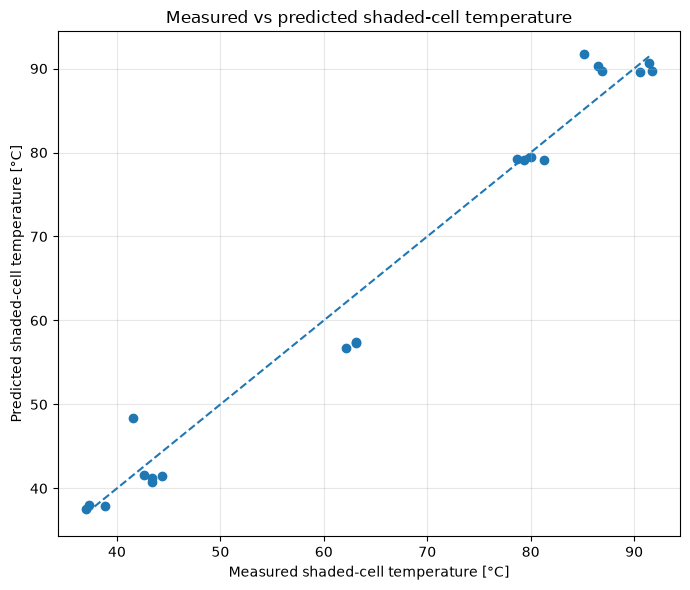

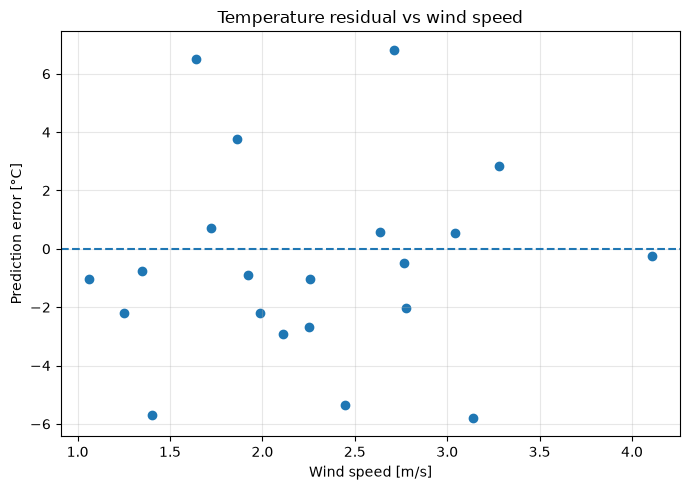

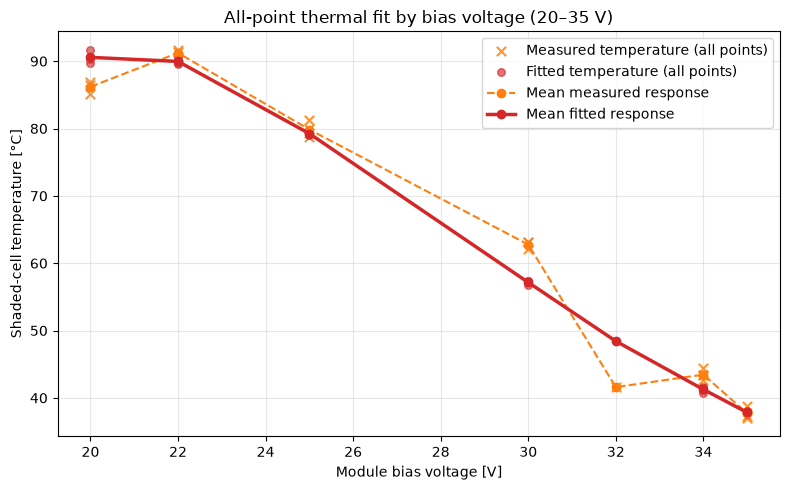

,Bias_V,n,T_measured_mean_C,T_predicted_mean_C
0,20.0,3,86.200000,90.569286
1,22.0,3,91.233333,89.967095
2,25.0,4,79.850000,79.249448
3,30.0,3,62.766667,57.149261
4,32.0,1,41.600000,48.423088
5,34.0,4,43.450000,41.250215
6,35.0,3,37.700000,37.834094


In [10]:
# ------------------------------------------------------------------
# Diagnostic plots
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(
    fit_df["T_shaded_measured_C"],
    fit_df["T_predicted_C"],
)

lo = min(
    fit_df["T_shaded_measured_C"].min(),
    fit_df["T_predicted_C"].min(),
)
hi = max(
    fit_df["T_shaded_measured_C"].max(),
    fit_df["T_predicted_C"].max(),
)

ax.plot([lo, hi], [lo, hi], "--")
ax.set_xlabel("Measured shaded-cell temperature [°C]")
ax.set_ylabel("Predicted shaded-cell temperature [°C]")
ax.set_title("Measured vs predicted shaded-cell temperature")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    fit_df["wind_speed_m_s"],
    fit_df["Error_C"],
)

ax.axhline(0.0, linestyle="--")
ax.set_xlabel("Wind speed [m/s]")
ax.set_ylabel("Prediction error [°C]")
ax.set_title("Temperature residual vs wind speed")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# All selected points plus the mean fitted response at each measured bias.
# Connecting the bias-group means makes the thermal-response shape easy to
# inspect without hiding the individual measurements.
bias_summary = (
    fit_df.groupby("Bias_V", as_index=False)
    .agg(
        n=("Bias_V", "size"),
        T_measured_mean_C=("T_shaded_measured_C", "mean"),
        T_predicted_mean_C=("T_predicted_C", "mean"),
    )
    .sort_values("Bias_V")
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    fit_df["Bias_V"],
    fit_df["T_shaded_measured_C"],
    color="tab:orange",
    marker="x",
    s=45,
    alpha=0.85,
    label="Measured temperature (all points)",
)
ax.scatter(
    fit_df["Bias_V"],
    fit_df["T_predicted_C"],
    color="tab:red",
    s=30,
    alpha=0.65,
    label="Fitted temperature (all points)",
)
ax.plot(
    bias_summary["Bias_V"],
    bias_summary["T_measured_mean_C"],
    "o--",
    color="tab:orange",
    linewidth=1.5,
    label="Mean measured response",
)
ax.plot(
    bias_summary["Bias_V"],
    bias_summary["T_predicted_mean_C"],
    "o-",
    color="tab:red",
    linewidth=2.5,
    label="Mean fitted response",
)
ax.set_xlabel("Module bias voltage [V]")
ax.set_ylabel("Shaded-cell temperature [°C]")
ax.set_title(
    f"All-point thermal fit by bias voltage "
    f"({BIAS_V_MIN:.0f}–{BIAS_V_MAX:.0f} V)"
)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

display(bias_summary)

## Optional diagnostic: fit coefficients separately for each shade percentage

The global fit above is the main result. This extra table is useful for checking whether the effective cell heat-loss coefficients appear to change systematically with shading condition. A shade group is only fit when it has at least 3 usable rows and at least 2 distinct wind speeds.

In [11]:
# ------------------------------------------------------------------
# Optional per-shade fits
# ------------------------------------------------------------------
per_shade_rows = []

for shade_pct, group in fit_df.groupby("Shade_Percentage"):
    g = group.dropna(
        subset=[
            "T_amb_C",
            "wind_speed_m_s",
            "q_total_W_m2",
            "T_shaded_measured_C",
        ]
    ).copy()

    if len(g) < 3 or g["wind_speed_m_s"].nunique() < 2:
        per_shade_rows.append({
            "Shade_Percentage": shade_pct,
            "n": len(g),
            "U0": np.nan,
            "U1": np.nan,
            "RMSE_C": np.nan,
            "R2": np.nan,
            "status": "not enough independent data",
        })
        continue

    try:
        X = (
            g["T_amb_C"].to_numpy(dtype=float),
            g["wind_speed_m_s"].to_numpy(dtype=float),
            g["q_total_W_m2"].to_numpy(dtype=float),
        )
        y = g["T_shaded_measured_C"].to_numpy(dtype=float)

        p, _ = curve_fit(
            faiman_cell_model,
            X,
            y,
            p0=[U0_fit, U1_fit],
            bounds=([0.001, 0.0], [np.inf, np.inf]),
            maxfev=100000,
        )

        pred = faiman_cell_model(X, *p)
        err = pred - y

        ss_res = np.sum((y - pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)

        per_shade_rows.append({
            "Shade_Percentage": shade_pct,
            "n": len(g),
            "U0": p[0],
            "U1": p[1],
            "RMSE_C": np.sqrt(np.mean(err ** 2)),
            "R2": 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan,
            "status": "ok",
        })

    except Exception as exc:
        per_shade_rows.append({
            "Shade_Percentage": shade_pct,
            "n": len(g),
            "U0": np.nan,
            "U1": np.nan,
            "RMSE_C": np.nan,
            "R2": np.nan,
            "status": f"{type(exc).__name__}: {exc}",
        })


per_shade_fit = pd.DataFrame(per_shade_rows).sort_values("Shade_Percentage")
display(per_shade_fit)

,Shade_Percentage,n,U0,U1,RMSE_C,R2,status
0,48.0,7,49.881119,4.629451e-15,2.779421,0.964420,ok
1,49.0,12,52.594647,6.200790e-14,2.966987,0.982268,ok
2,50.0,2,NaN,NaN,NaN,NaN,not enough independent data


In [12]:
# # ------------------------------------------------------------------
# # Save the complete row-by-row electrical results and fitted results
# # ------------------------------------------------------------------
# output_dir = project_root / "docs" / "data" / "IVshaded"

# electrical_csv = output_dir / "thermal_fit_electrical_results.csv"
# fit_csv = output_dir / "thermal_fit_results.csv"
# shade_csv = output_dir / "thermal_fit_by_shade.csv"

# electrical_results.to_csv(electrical_csv, index=False)
# fit_df.to_csv(fit_csv, index=False)
# per_shade_fit.to_csv(shade_csv, index=False)

# print("Saved:")
# print(electrical_csv)
# print(fit_csv)
# print(shade_csv)